# MEDIDAS DE DISPERSIÓN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

penguins_df = sns.load_dataset('penguins')
penguins_df.dropna(inplace=True)
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# RANGO

## MAXIMO

In [2]:
penguins_df.max(numeric_only=True)

,0
bill_length_mm,59.6
bill_depth_mm,21.5
flipper_length_mm,231.0
body_mass_g,6300.0


# MINIMO

In [3]:
penguins_df.min(numeric_only=True)

,0
bill_length_mm,32.1
bill_depth_mm,13.1
flipper_length_mm,172.0
body_mass_g,2700.0


# RANGO = MAX - MIN

In [4]:
rango = penguins_df.max(numeric_only=True) - penguins_df.min(numeric_only=True)
rango

,0
bill_length_mm,27.5
bill_depth_mm,8.4
flipper_length_mm,59.0
body_mass_g,3600.0


# DESVIACIÓN STANDARD

In [5]:
penguins_df.std(numeric_only=True)

,0
bill_length_mm,5.468668
bill_depth_mm,1.969235
flipper_length_mm,14.015765
body_mass_g,805.215802


# RANGO INTECUARTILICO

# Q1 = 25%

In [6]:
penguins_df.quantile(0.25,numeric_only=True)

,0.25
bill_length_mm,39.5
bill_depth_mm,15.6
flipper_length_mm,190.0
body_mass_g,3550.0


# Q3 = 75%

In [7]:
penguins_df.quantile(0.75,numeric_only=True)

,0.75
bill_length_mm,48.6
bill_depth_mm,18.7
flipper_length_mm,213.0
body_mass_g,4775.0


# RANGO DE Q1 - Q3

In [8]:
rango_intercuartilico = penguins_df.quantile(0.75,numeric_only=True) - penguins_df.quantile(0.25,numeric_only=True)
rango_intercuartilico

,0
bill_length_mm,9.1
bill_depth_mm,3.1
flipper_length_mm,23.0
body_mass_g,1225.0


# MOSTRAMOS TODOS LOS DATOS

In [10]:
(
    penguins_df
    .quantile(q=[0.75,0.50,0.25],numeric_only=True)
    .transpose()
    .rename_axis('metric')
    .reset_index()
    .assign(
        iqr = lambda x: x[0.75] - x[0.25]
    )
)

,metric,0.75,0.5,0.25,iqr
0,bill_length_mm,48.6,44.5,39.5,9.1
1,bill_depth_mm,18.7,17.3,15.6,3.1
2,flipper_length_mm,213.0,197.0,190.0,23.0
3,body_mass_g,4775.0,4050.0,3550.0,1225.0


# GRAFICO

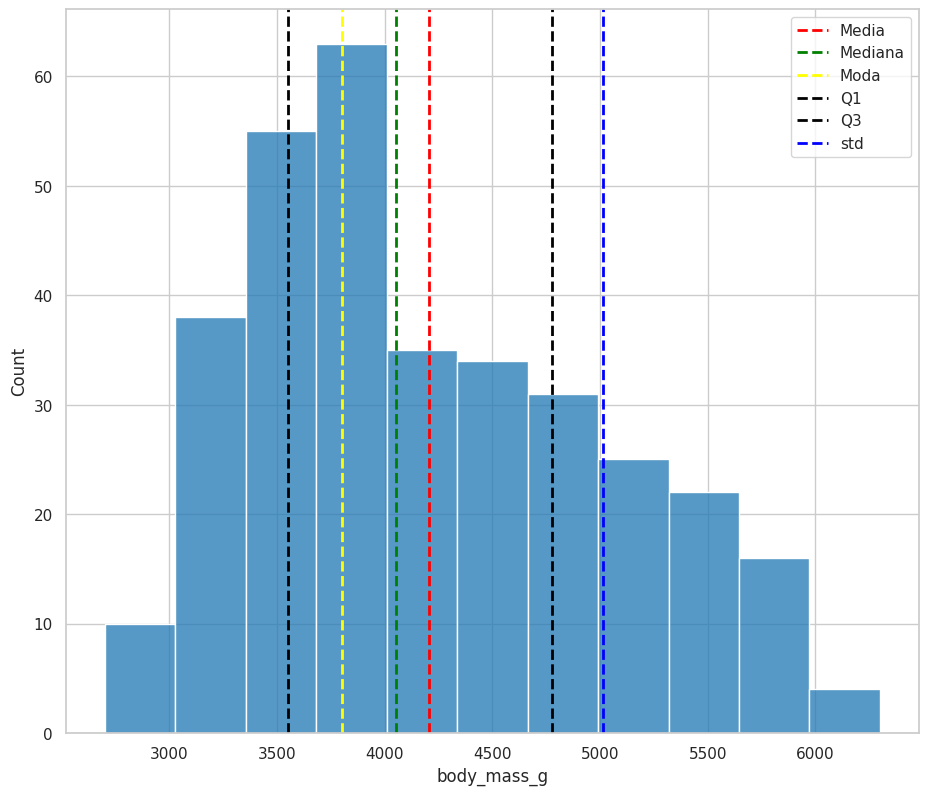

In [12]:
variable = 'body_mass_g'

sns.histplot(
    data=penguins_df,
    x=variable
)

# MEDIA
plt.axvline(
    x=penguins_df[variable].mean(),
    label='Media',
    color='red',
    linestyle='dashed',
    linewidth=2
)

# MEDIANA
plt.axvline(
    x=penguins_df[variable].median(),
    label='Mediana',
    color='green',
    linestyle='dashed',
    linewidth=2
)

#MODA
plt.axvline(
    x=penguins_df[variable].mode().values[0],
    label='Moda',
    color='yellow',
    linestyle='dashed',
    linewidth=2
)


#Q 25
plt.axvline(
    x=penguins_df[variable].quantile(0.25),
    label='Q1',
    color='black',
    linestyle='dashed',
    linewidth=2
)

#Q 75
plt.axvline(
    x=penguins_df[variable].quantile(0.75),
    label='Q3',
    color='black',
    linestyle='dashed',
    linewidth=2
)


# std
plt.axvline(
    x=penguins_df[variable].mean() + penguins_df[variable].std(),
    label='std',
    color='blue',
    linestyle='dashed',
    linewidth=2
)

plt.legend()

plt.show()